In [199]:
def prepare_coordinates(cell_centroids, existing_coords):
    """
    Convert everything into consistent numpy arrays in projected CRS units.
    """

    cell_coords = np.vstack([
        np.array([geom.x, geom.y]) 
        for geom in cell_centroids.geometry
    ])

    existing_coords = np.asarray(existing_coords)

    return cell_coords, existing_coords

def greedy_selection(cluster_candidates,
                      cell_coords,
                      existing_coords,
                      min_dist):
    """
    Greedy selection with strict spatial constraints.

    Returns:
        dict: {cluster_id: cell_index}
    """

    selected = {}              # cluster_id -> cell_index
    selected_idx = []          # list of chosen indices (for distance checks)

    for cluster_id, candidates in cluster_candidates.items():

        chosen = None

        for idx in candidates:

            candidate_xy = cell_coords[idx]

            # -------------------------------------------------
            # 1. Check against already selected points
            # -------------------------------------------------
            if selected_idx:
                d_sel = np.linalg.norm(
                    cell_coords[selected_idx] - candidate_xy,
                    axis=1
                )
                if np.any(d_sel < min_dist):
                    continue

            # -------------------------------------------------
            # 2. Check against existing gauges
            # -------------------------------------------------
            if len(existing_coords) > 0:
                d_exist = np.linalg.norm(existing_coords - candidate_xy, axis=1)
                if np.any(d_exist < min_dist):
                    continue

            # -------------------------------------------------
            # If valid, accept
            # -------------------------------------------------
            chosen = idx
            break

        # store result (if any valid candidate exists)
        if chosen is not None:
            selected[cluster_id] = chosen
            selected_idx.append(chosen)

    return selected

def run_greedy(cluster_candidates,
               cell_centroids,
               existing_coords,
               min_dist):

    # --- enforce consistent coordinate system ---
    cell_coords, existing_coords = prepare_coordinates(
        cell_centroids,
        existing_coords
    )

    solution = greedy_selection(
        cluster_candidates,
        cell_coords,
        existing_coords,
        min_dist
    )

    return solution

def shuffle_greedy(cluster_candidates,
                   cell_centroids,
                   existing_coords,
                   min_dist,
                   n_iterations=500):

    best_solution = None
    best_score = (-1, 0)

    cluster_keys = list(cluster_candidates.keys())

    for _ in range(n_iterations):

        # --------------------------------------------------
        # shuffle cluster order (this is the key idea)
        # --------------------------------------------------
        random.shuffle(cluster_keys)

        shuffled_candidates = {
            c: cluster_candidates[c]
            for c in cluster_keys
        }

        # --------------------------------------------------
        # run greedy on shuffled order
        # --------------------------------------------------
        solution = greedy_selection(
            shuffled_candidates,
            cell_centroids,
            existing_coords,
            min_dist
        )

        # --------------------------------------------------
        # score solution
        # --------------------------------------------------
        s = score(solution, cluster_candidates)

        if s > best_score:
            best_score = s
            best_solution = solution

    print(f"\nBest shuffle-greedy solution:")
    print(f"  clusters covered: {best_score[0]}")
    print(f"  rank score: {-best_score[1]}")

    return best_solution

def check_solution(solution,
                   cell_coords,
                   existing_coords,
                   min_dist):

    selected_idx = list(solution.values())
    selected_coords = cell_coords[selected_idx]

    # --- check selected vs selected ---
    if len(selected_coords) > 1:
        d_sel = cdist(selected_coords, selected_coords)
        np.fill_diagonal(d_sel, np.inf)
        print("Min selected-selected distance:", d_sel.min())

    # --- check selected vs existing ---
    if len(existing_coords) > 0:
        d_exist = cdist(selected_coords, existing_coords)
        min_d = d_exist.min()

        print("Min selected-existing distance:", min_d)

        violations = np.where(d_exist < min_dist)

        if len(violations[0]) > 0:
            print("🚨 Violations found:")
            for i, j in zip(*violations):
                print(f"  selected {selected_idx[i]} too close to existing {j}")
                
                
def score_solution(solution, cluster_candidates):
    """
    Higher is better:
    - more clusters covered
    - tie-break: prefer earlier-ranked candidates
    """

    n_covered = len(solution)

    rank_penalty = 0
    for c, idx in solution.items():
        if c in cluster_candidates:
            rank_penalty += list(cluster_candidates[c]).index(idx)
#             rank_penalty += cluster_candidates[c].index(idx)

    return (n_covered, -rank_penalty)

import copy
import random
import numpy as np

def get_neighbour(solution,
                  cluster_candidates,
                  cell_coords,
                  existing_coords,
                  min_dist):

    new_solution = copy.deepcopy(solution)

    # pick random cluster
    cluster_id = random.choice(list(cluster_candidates.keys()))
    candidates = cluster_candidates[cluster_id]

    current = new_solution.get(cluster_id, None)

    # try alternative candidates
    for idx in candidates:

        if idx == current:
            continue

        candidate_xy = cell_coords[idx]

        # --- check against existing ---
        if len(existing_coords) > 0:
            if np.any(np.linalg.norm(existing_coords - candidate_xy, axis=1) < min_dist):
                continue

        # --- check against current solution ---
        ok = True
        for c, sel_idx in new_solution.items():
            if c == cluster_id:
                continue
            if np.linalg.norm(cell_coords[sel_idx] - candidate_xy) < min_dist:
                ok = False
                break

        if ok:
            new_solution[cluster_id] = idx
            return new_solution

    return solution

import math

def simulated_annealing(initial_solution,
                        cluster_candidates,
                        cell_coords,
                        existing_coords,
                        min_dist,
                        T0=1.0,
                        Tmin=0.001,
                        alpha=0.995,
                        n_iter=5000):

    current = dict(initial_solution)
    current_score = score_solution(current, cluster_candidates)

    best = dict(current)
    best_score = current_score

    T = T0

    for _ in range(n_iter):

        neighbour = get_neighbour(
            current,
            cluster_candidates,
            cell_coords,
            existing_coords,
            min_dist
        )

        neighbour_score = score_solution(neighbour, cluster_candidates)

        delta = neighbour_score[1] - current_score[1]

        # accept rule
        if delta > 0 or random.random() < math.exp(delta / T):
            current = neighbour
            current_score = neighbour_score

            if current_score > best_score:
                best = dict(current)
                best_score = current_score

        T *= alpha
        if T < Tmin:
            break

    print(f"SA complete: clusters={best_score[0]}, rank_score={-best_score[1]}")
    return best

def ilp_solution(cluster_candidates,
                 cell_coords,
                 existing_coords,
                 min_dist):

    prob = LpProblem("gauge_placement", LpMinimize)

    # --------------------------------------------------
    # Decision variables
    # --------------------------------------------------
    x = {}

    for c, candidates in cluster_candidates.items():
        for rank, idx in enumerate(candidates):
            x[(c, idx)] = LpVariable(f"x_{c}_{idx}", cat="Binary")

    # --------------------------------------------------
    # Objective: minimise rank penalty
    # --------------------------------------------------
    prob += lpSum(
        rank * x[(c, idx)]
        for c, candidates in cluster_candidates.items()
        for rank, idx in enumerate(candidates)
    )

    # --------------------------------------------------
    # Constraint 1: one per cluster
    # --------------------------------------------------
    for c, candidates in cluster_candidates.items():
        prob += lpSum(x[(c, idx)] for idx in candidates) == 1

    # --------------------------------------------------
    # Precompute all candidate coords
    # --------------------------------------------------
    coords = {
        idx: cell_coords[idx]
        for c in cluster_candidates
        for idx in cluster_candidates[c]
    }

    # --------------------------------------------------
    # Constraint 2: min distance between ALL selected points
    # --------------------------------------------------
    all_items = [(c, idx) for c, candidates in cluster_candidates.items()
                         for idx in candidates]

    for i in range(len(all_items)):
        c1, idx1 = all_items[i]

        for j in range(i + 1, len(all_items)):
            c2, idx2 = all_items[j]

            # skip same cluster pairs (already handled)
            if c1 == c2:
                continue

            if np.linalg.norm(coords[idx1] - coords[idx2]) < min_dist:
                prob += x[(c1, idx1)] + x[(c2, idx2)] <= 1

    # --------------------------------------------------
    # Constraint 3: min distance between ALL selected points
    # --------------------------------------------------                
    for c, candidates in cluster_candidates.items():
        for idx in candidates:

            candidate_xy = cell_coords[idx]

            for j, ex in enumerate(existing_coords):

                if np.linalg.norm(candidate_xy - ex) < min_dist:

                    # forbid this candidate entirely
                    prob += x[(c, idx)] == 0                


    # --------------------------------------------------
    # Solve
    # --------------------------------------------------
    prob.solve(PULP_CBC_CMD(msg=0))

    print("ILP status:", LpStatus[prob.status])

    # --------------------------------------------------
    # Extract solution
    # --------------------------------------------------
    solution = {}

    for c, candidates in cluster_candidates.items():
        for idx in candidates:
            if value(x[(c, idx)]) == 1:
                solution[c] = idx

    return solution

ILP status: Optimal

--- GREEDY ---

🔍 Selected → Existing distances (min per point):
  Point 0: 3484.9 m
  Point 1: 2504.5 m
  Point 2: 3386.8 m
  Point 3: 4011.5 m
  Point 4: 2897.4 m
  Point 5: 3439.6 m
  Point 6: 3180.4 m
  Point 7: 4364.4 m
  Point 8: 3116.2 m

Overall min selected-existing: 2504.513784939832

🔍 Selected → Selected min distance: 2500.1679367710717


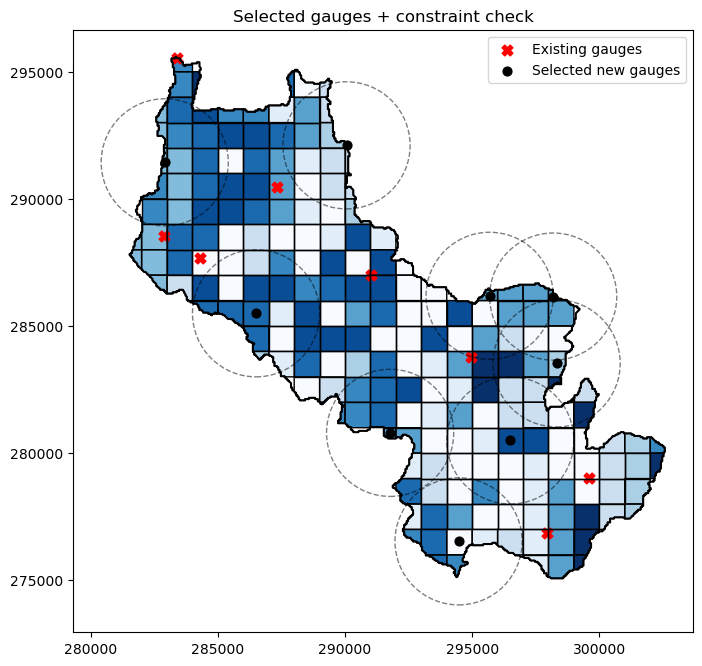


--- SHUFFLE GREEDY ---

🔍 Selected → Existing distances (min per point):
  Point 0: 3439.6 m
  Point 1: 3567.6 m
  Point 2: 3484.9 m
  Point 3: 2897.4 m
  Point 4: 4364.4 m
  Point 5: 2914.2 m
  Point 6: 3180.4 m
  Point 7: 3386.8 m
  Point 8: 3116.2 m
  Point 9: 4635.5 m

Overall min selected-existing: 2897.418949654873

🔍 Selected → Selected min distance: 2896.9237010239503


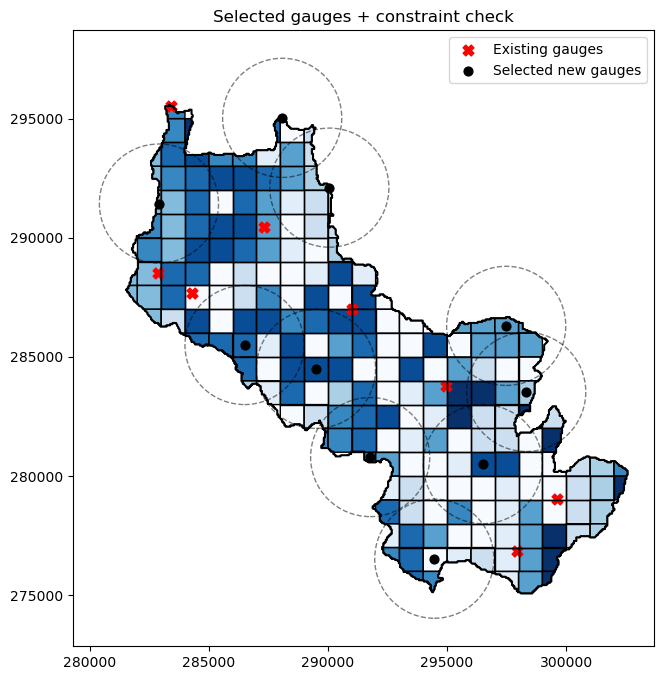


--- Simulated annealing ---

🔍 Selected → Existing distances (min per point):
  Point 0: 3484.9 m
  Point 1: 2504.5 m
  Point 2: 3386.8 m
  Point 3: 4011.5 m
  Point 4: 2897.4 m
  Point 5: 3439.6 m
  Point 6: 3180.4 m
  Point 7: 4364.4 m
  Point 8: 3116.2 m

Overall min selected-existing: 2504.513784939832

🔍 Selected → Selected min distance: 2500.1679367710717


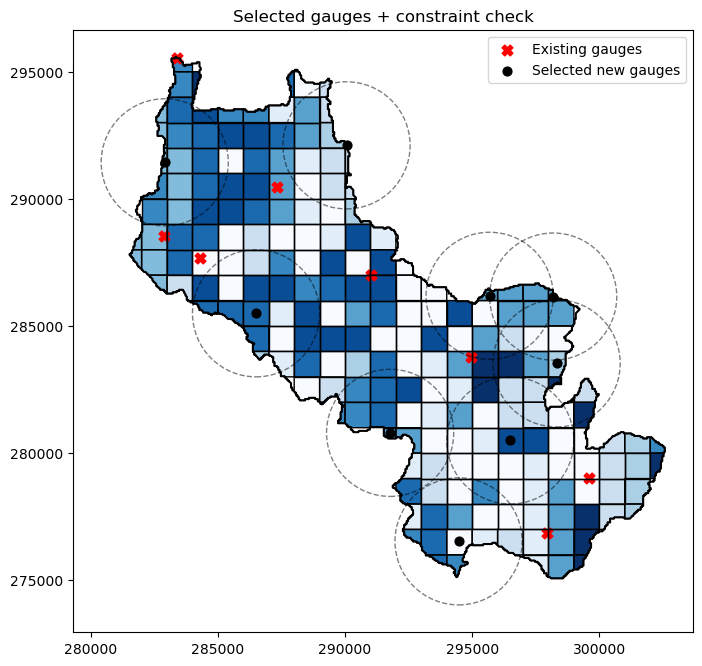


--- ILP ---

🔍 Selected → Existing distances (min per point):
  Point 0: 3484.9 m
  Point 1: 4635.5 m
  Point 2: 3386.8 m
  Point 3: 2914.2 m
  Point 4: 2897.4 m
  Point 5: 3439.6 m
  Point 6: 3180.4 m
  Point 7: 4364.4 m
  Point 8: 3116.2 m
  Point 9: 3567.6 m

Overall min selected-existing: 2897.418949654873

🔍 Selected → Selected min distance: 2896.9237010239503


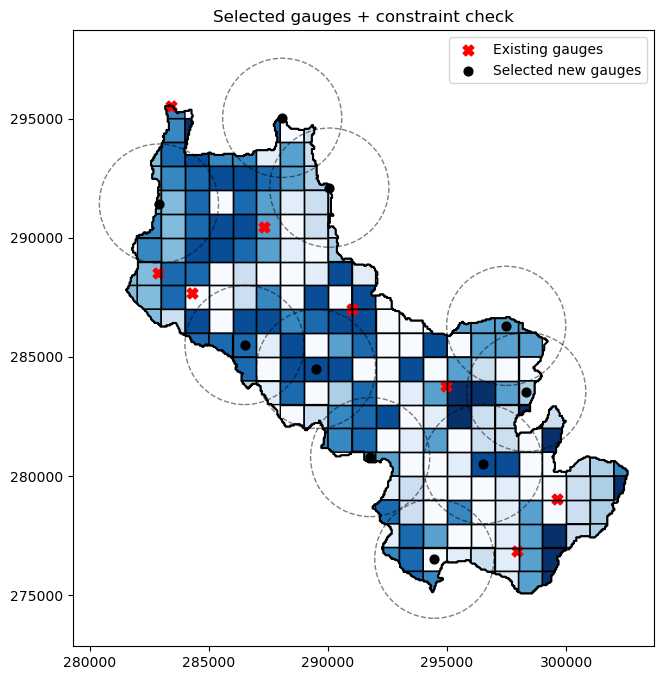

In [200]:
# # 1. greedy baseline
# greedy_solution = greedy_selection(
#     cluster_candidates,
#     cell_coords,
#     existing_coords,
#     min_dist
# )

# # 2. shuffle-greedy improvement
# shuffle_solution = shuffle_greedy(
#     cluster_candidates,
#     cell_coords,
#     existing_coords,
#     min_dist,
#     n_iterations=500
# )

# sa_solution = simulated_annealing(
#     greedy_solution,
#     cluster_candidates,
#     cell_coords,
#     existing_coords,
#     min_dist
# )

ilp_solution_result = ilp_solution(
    cluster_candidates,
    cell_coords,
    existing_coords,
    min_dist
)

# 3. check both
print("\n--- GREEDY ---")
plot_and_check(greedy_solution, cell_centroids, existing_coords, min_dist)

print("\n--- SHUFFLE GREEDY ---")
plot_and_check(shuffle_solution, cell_centroids, existing_coords, min_dist)

print("\n--- Simulated annealing ---")
plot_and_check(sa_solution, cell_centroids, existing_coords, min_dist)

print("\n--- ILP ---")
plot_and_check(ilp_solution_result, cell_centroids, existing_coords, min_dist)


🔍 Selected → Existing distances (min per point):
  Point 0: 3484.9 m
  Point 1: 2504.5 m
  Point 2: 3386.8 m
  Point 3: 4011.5 m
  Point 4: 2897.4 m
  Point 5: 3439.6 m
  Point 6: 3180.4 m
  Point 7: 4364.4 m
  Point 8: 3116.2 m

Overall min selected-existing: 2504.513784939832

🔍 Selected → Selected min distance: 2500.1679367710717


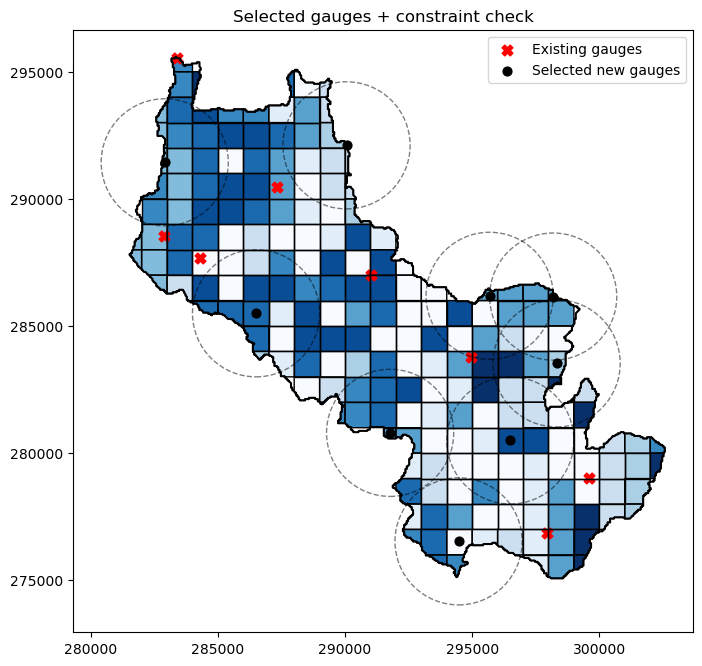

In [182]:


# fig,ax=plt.subplots(figsize=(12,10))
# greedy_cells = list(solution.values())
# plot_selected_cells(ax, greedy_cells, min_dist)
# ax.axis('off')

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

def plot_and_check(solution,
                   cell_centroids,
                   existing_coords,
                   min_dist,
                   ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    # --------------------------------------------------            
    catchment_Dolwen.boundary.plot(ax=ax, color="black")     
    grid_1km.plot(column="cluster",categorical=True,legend=False,ax=ax,alpha=1 , cmap='Blues')
    grid_1km.boundary.plot(ax=ax, color="black", linewidth=1) # Grid outlines        
        
    # --------------------------------------------------
    # Extract selected points
    # --------------------------------------------------
    selected_idx = list(solution.values())

    selected_coords = np.vstack([
        np.array([cell_centroids[i].x,
                  cell_centroids[i].y])
        for i in selected_idx
    ])
    
    existing_coords = np.asarray(existing_coords)

    # --------------------------------------------------
    # Plot base data (optional but useful)
    # --------------------------------------------------
    ax.scatter(existing_coords[:, 0],
               existing_coords[:, 1],
               c="red", marker = "X", 
               label="Existing gauges",
               s=60)

    ax.scatter(selected_coords[:, 0],
               selected_coords[:, 1],
               c="black",
               label="Selected new gauges",
               s=40)

    # --------------------------------------------------
    # Draw buffer circles (true constraint radius)
    # --------------------------------------------------
    for x, y in selected_coords:
        circle = plt.Circle((x, y),
                            min_dist,
                            fill=False,
                            linestyle="--",
                            color="black",
                            alpha=0.5)
        ax.add_patch(circle)

    # --------------------------------------------------
    # DISTANCE CHECK: selected vs existing
    # --------------------------------------------------
    if len(existing_coords) > 0:
        d_exist = cdist(selected_coords, existing_coords)

        print("\n🔍 Selected → Existing distances (min per point):")
        for i in range(len(selected_coords)):
            min_d = d_exist[i].min()
            print(f"  Point {i}: {min_d:.1f} m")

            if min_d < min_dist:
                j = np.argmin(d_exist[i])
                print(f"  🚨 VIOLATION: Point {i} is {min_d:.1f} m from existing {j}")

        print("\nOverall min selected-existing:",
              d_exist.min())

    # --------------------------------------------------
    # DISTANCE CHECK: selected vs selected
    # --------------------------------------------------
    if len(selected_coords) > 1:
        d_sel = cdist(selected_coords, selected_coords)
        np.fill_diagonal(d_sel, np.inf)

        min_sel = d_sel.min()
        print("\n🔍 Selected → Selected min distance:", min_sel)

        if min_sel < min_dist:
            i, j = np.unravel_index(np.argmin(d_sel), d_sel.shape)
            print(f"🚨 VIOLATION between {i} and {j}")

    # --------------------------------------------------
    # Final plot formatting
    # --------------------------------------------------
    ax.set_title("Selected gauges + constraint check")
    ax.legend()
    ax.set_aspect("equal")

    plt.show()
    

plot_and_check(
    solution,
    cell_centroids,
    existing_coords,
    min_dist
)    

In [154]:
import random
import math
from scipy.optimize import linprog
from pulp import *

def plot_selected_cells(ax, selected_cells, min_dist):
    
    gauge_locations = grid_1km.iloc[selected_cells].copy()
    gauge_points = gauge_locations.copy()
    gauge_points["geometry"] = gauge_points.geometry.centroid

    # grid_1km.plot(column="cluster",categorical=True,legend=True,ax=ax,alpha=1 , cmap='viridis')
    grid_1km.plot(column="cluster",categorical=True,legend=False,ax=ax,alpha=1 , cmap='Blues')
    grid_1km.boundary.plot(ax=ax, color="black", linewidth=1) # Grid outlines
    catchment_Dolwen.boundary.plot(ax=ax, color="black")
    gauge_points.plot(ax=ax,color="black", markersize=30,label="Selected gauge locations")
    rain_meta_sf.plot(ax=ax, color="red", markersize=50, marker = "X", zorder=5)

    for pt in gauge_points.geometry:
        circle = plt.Circle((pt.x, pt.y), min_dist/2, color='red', fill=False, linestyle='--')
        ax.add_patch(circle)

    # After selection, verify no two selected cells are too close
    coords = np.array([(cell_centroids.iloc[i].x, cell_centroids.iloc[i].y) 
                       for i in selected_cells])
    dist_matrix = cdist(coords, coords)
    np.fill_diagonal(dist_matrix, np.inf)  # ignore self-distances
    print("Minimum distance between selected cells:", dist_matrix.min())
    print("Any violations?", (dist_matrix < min_dist).any())   

#     for i, coord in enumerate(coords):
#         for j, ex in enumerate(existing_coords):
#             dist = np.linalg.norm(coord - ex)

#             print(f"Distance: new {i} → existing {j} = {dist:.1f} m")

#             if dist < min_dist:
#                 print(f"🚨 VIOLATION: new {i} is {dist:.1f} m from existing {j}")
    
    # check against existing gauges
    for i, coord in enumerate(coords):
        for ex in existing_coords:
            dist = np.linalg.norm(coord - ex)
            if dist < min_dist:
                print(f"Gauge {i} too close to existing gauge")
                
def greedy_selection(cluster_candidates, cell_centroids, existing_coords, min_dist):
    """Single greedy pass. Returns (selected_cells, n_valid_clusters)."""
    selected_cells = []
    selected_cluster_ids = []
    
    for c in cluster_candidates:
        candidates = cluster_candidates[c]
        chosen = None
        for idx in candidates:
            
            #print("idx:", idx)
            #print("centroid:", cell_centroids.iloc[idx])
            
            candidate_point = cell_centroids.iloc[idx]
            too_close = False
            for sel in selected_cells:
                if candidate_point.distance(cell_centroids.iloc[sel]) < min_dist:
                    too_close = True
                    break
            if not too_close:
                for ex in existing_coords:
                    dist = np.linalg.norm(
                        np.array([candidate_point.x, candidate_point.y]) - ex
                    )
                    if dist < min_dist:
                        too_close = True
                        break
#             if not too_close:
#                 chosen = idx
#                 break
                
            if not too_close:
                # 🔍 final check before accepting
                for ex in existing_coords:
                    dist = np.linalg.norm(
                        np.array([candidate_point.x, candidate_point.y]) - ex
                    )
                    if dist < min_dist:
                        print("🚨 SHOULD NOT HAPPEN")
                        print("Distance:", dist)
                        print("Candidate idx:", idx)

                chosen = idx
                break                

        if chosen is not None:
            selected_cells.append(chosen)
            selected_cluster_ids.append(c)
    
    solution = dict(zip(selected_cluster_ids, selected_cells))
    return solution






def shuffle_greedy(cluster_candidates, min_dist):
    
    n_iterations = 500
    best_solution = None
    best_score = (-1, 0)

    cluster_list = list(cluster_candidates.keys())

    for _ in range(n_iterations):
        random.shuffle(cluster_list)
        
        shuffled = {c: cluster_candidates[c] for c in cluster_list}
        
        solution = greedy_selection(
            shuffled, cell_centroids, existing_coords, min_dist
        )
        
        s = score(solution, cluster_candidates)
        
        if s > best_score:
            best_score = s
            best_solution = solution

    print(f"Best solution covers {best_score[0]}/{len(cluster_candidates)} clusters")
    print(f"Best rank sum: {-best_score[1]}")
    
    return best_solution

# Score a solution: more clusters covered = better;
# tiebreak on sum of candidate ranks (lower = higher quality candidates chosen)
def score(solution, cluster_candidates):
    n_covered = len(solution)
    
    rank_sum = sum(
        list(cluster_candidates[c]).index(cell)
        for c, cell in solution.items()
        if c in cluster_candidates)
    
    return (n_covered, -rank_sum)

def get_neighbour(solution, cluster_candidates, cell_centroids, existing_coords, min_dist):
    import copy
    new_solution = copy.copy(solution)
    
    # Pick a random cluster
#     c = random.choice(list(cluster_candidates.keys()))
    c = random.choice(list(solution.keys()))
    
    candidates = list(cluster_candidates[c])
    current_choice = new_solution.get(c, None)
    
    # Find next candidates
    if current_choice in candidates:
        current_rank = candidates.index(current_choice)
        next_candidates = candidates[current_rank + 1:]
    else:
        next_candidates = candidates
    
    for new_idx in next_candidates:
        new_solution[c] = new_idx
        
        # Validate full solution
        coords = np.array([
            (cell_centroids.iloc[i].x, cell_centroids.iloc[i].y)
            for i in new_solution.values()])
        
        dist_matrix = cdist(coords, coords)
        np.fill_diagonal(dist_matrix, np.inf)
        
        if dist_matrix.min() >= min_dist:
            # Check against existing gauges
            valid = True
            for coord in coords:
                for ex in existing_coords:
                    if np.linalg.norm(coord - ex) < min_dist:
                        valid = False
                        break
            
            if valid:
                return new_solution
    
    return solution


def simulated_annealing(initial_solution, cluster_candidates):

    current_solution = dict(initial_solution)
    current_score = score(current_solution, cluster_candidates)[1]

    T = 1.0
    T_min = 0.001
    alpha = 0.995

    while T > T_min:
        neighbour = get_neighbour(current_solution, cluster_candidates, cell_centroids, existing_coords, min_dist)
        
        delta = score(neighbour, cluster_candidates)[1] - current_score

        if delta > 0 or random.random() < math.exp(delta / T):
            current_solution = neighbour
            current_score += delta

        T *= alpha

    return current_solution

def ilp (cluster_candidates, min_dist):

    # One binary variable x[c][i] = 1 if candidate i is chosen for cluster c
    prob = LpProblem("gauge_placement", LpMinimize)

    x = {}
    for c, candidates in cluster_candidates.items():
        for rank, idx in enumerate(candidates):
            x[(c, idx)] = LpVariable(f"x_{c}_{idx}", cat='Binary')

    # Objective: minimise total rank (prefer top-ranked candidates)
    prob += lpSum(rank * x[(c, idx)] 
                  for c, candidates in cluster_candidates.items() 
                  for rank, idx in enumerate(candidates))

    # Constraint 1: select exactly one candidate per cluster
    for c, candidates in cluster_candidates.items():
        prob += lpSum(x[(c, idx)] for idx in candidates) == 1

    # Constraint 2: no two selected points within min_dist
    # (pairwise constraint across all candidates from different clusters)
    all_candidates = [
        (c, idx) for c, candidates in cluster_candidates.items() 
        for idx in candidates]
    for i, (c1, idx1) in enumerate(all_candidates):
        for j, (c2, idx2) in enumerate(all_candidates):
            if c1 >= c2:
                continue
            p1 = cell_centroids.iloc[idx1]
            p2 = cell_centroids.iloc[idx2]
            if p1.distance(p2) < min_dist:
                # Can't both be selected
                prob += x[(c1, idx1)] + x[(c2, idx2)] <= 1

    # Constraint 3: no candidate can be within min_dist of existing gauges
    for c, candidates in cluster_candidates.items():
        for idx in candidates:
            p = cell_centroids.iloc[idx]

            for ex in existing_coords:
                dist = np.linalg.norm(
                    np.array([p.x, p.y]) - ex
                )

                if dist < min_dist:
                    # This candidate is invalid → force it to 0
                    prob += x[(c, idx)] == 0                

    prob.solve(PULP_CBC_CMD(msg=0))
    print(f"Status: {LpStatus[prob.status]}")

    selected_cells = []
    for c, candidates in cluster_candidates.items():
        for idx in candidates:
            if value(x[(c, idx)]) == 1:
                selected_cells.append(idx)
    return selected_cells

<div style="background-color: lightblue; color: black; border: 2px solid black; 
padding: 15px 25px; border-radius: 8px; margin: 10px 0px;">

  <h2 style="color: black; margin: 0px 0px 10px 0px;">
   Rain gauge optimisation
  </h2>

  <hr style="border: 1px solid black; margin: 10px 0px;">

  <p>This code works on defining optimal locations for placements of new rain gauges in the Upper Severn catchment. The placement of the gauges aims to optimise the accuracy with which rainfall over the catchment can be predicted. </p>

  <p><strong>The following data is available:</strong></p>
  <ul>
    <li> 1km HAD-UK gridded annual (?) rainfall data </li>
    <li> Rain gauge data from 10? existing rain gauges</li>
    <li> 30m (?) DEM data: from which slope and aspect can be derived. These are then aggregated to 1km </li>      
  </ul>
<!-- 
  <div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    <strong>NB:</strong> The threshold for an "unphysical" value is 
    currently set at <strong>150mm/hr</strong> — selected relatively 
    arbitrarily and may need review.
  </div> -->

</div>

In [1]:
import pandas as pd
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import folium
import pickle
from shapely.ops import unary_union
import rioxarray
import xarray as xr
from pathlib import Path
from rasterio.enums import Resampling
from rasterio.features import rasterize
from shapely.geometry import box
from scipy.spatial.distance import cdist

data_dir = "/scratch/hydro4/users/kv25483/FDRI/Rain_gauge_optimisation/Data/"

In [2]:
# Load Plynlimon catchments shapefile
Plyn_catch = gpd.read_file(data_dir + "Headwater_catchments/Plyn_catchments/data/Shapefile/"
    "ee2eeee5-e456-4e93-87e9-eee97ee149ee/PlynlimonCatchments.shp").set_crs(epsg=27700, allow_override=True)

# Load Plynlimon river network
Plyn_RN = gpd.read_file(data_dir + "Headwater_catchments/Plyn_rivernet/data/Shapefile/PlynlimonRiverNetwork.shp").set_crs(
    epsg=27700, allow_override=True)

# Load 2023 Land Cover data from CEH (10m res)
catchment_LMC = rioxarray.open_rasterio(data_dir + "lmc2023 clip.tif")

# Load DEMs
dem_Dolwen_1m = rioxarray.open_rasterio(data_dir + "dem_Dolwen_1m.tif")
dem_Dolwen    = rioxarray.open_rasterio(data_dir + "dem_Dolwen.tif")
dem_wider     = rioxarray.open_rasterio(data_dir +  "dem_Dolwen_wider.tif")

# Load other shapefiles
catchment_Dolwen = gpd.read_file(data_dir + "54080/54080.shp")
river_net_wider = gpd.read_file(data_dir + "54080_river_net/StreamLine_54080.shp").set_crs(epsg=27700)
river_net_Dolwen = gpd.read_file(data_dir + "river_net_Dolwen.shp")
river_net_CEH = gpd.read_file(data_dir + "River_net/DigitalRiverNetwork_50K_GB.shp").set_crs(epsg=27700)

# ==============================================================
# Load Soil Info
# ==============================================================
BGS_soil_shp = gpd.read_file(data_dir + "BGS_soil_parent.shp")

# Load and reproject HOST raster to EPSG:27700
BGS_HOST = rioxarray.open_rasterio(data_dir + "HOST.tif")
BGS_HOST = BGS_HOST.rio.reproject("EPSG:27700")

# Clip soil polygon to Dolwen catchment
BGS_soil_Dolwen = gpd.overlay(BGS_soil_shp, catchment_Dolwen, how="intersection")

# Mask HOST raster to Dolwen catchment
BGS_HOST_Dolwen = BGS_HOST.rio.clip(catchment_Dolwen.geometry, crs=catchment_Dolwen.crs, drop=True)

# ==============================================================
# Spatial Intersections
# ==============================================================

# Clip Plynlimon river network to Dolwen catchment
Plyn_RN_S = gpd.overlay(Plyn_RN, catchment_Dolwen, how="intersection")

# Filter Plynlimon catchments to Severn only
Plyn_catch_S = Plyn_catch[Plyn_catch["Catchment"] == "Severn"]

# Intersect Dolwen river network with Severn Plynlimon catchment
Plyn_RN_S_10k = gpd.overlay(river_net_Dolwen, Plyn_catch_S, how="intersection")

# ==============================================================
# Load Gauge and Weather Station Locations
# ==============================================================
plyn_sites = pd.read_csv(data_dir+ "Headwater_catchments/Plyn_sites_meta.csv")

# Convert to GeoDataFrame using BNG coordinates
plyn_sites_bng = gpd.GeoDataFrame(plyn_sites, geometry=gpd.points_from_xy(plyn_sites["x"], plyn_sites["y"]), crs="EPSG:27700")

### Get rain gauge data

In [3]:
# Load rain gauge metadata
rain_meta_cmd = pd.read_csv(data_dir + "rain_meta_for_CMD.csv")

# Convert to GeoDataFrame (BNG coordinates)
rain_meta_sf = gpd.GeoDataFrame(rain_meta_cmd, geometry=gpd.points_from_xy(rain_meta_cmd["x_2"], rain_meta_cmd["y_2"]),
                                crs="EPSG:27700")

# CRS definitions (for reference)
ukgrid  = "EPSG:27700"
latlong = "EPSG:4326"

### Get gridded rainfall data

In [4]:
HAD_names = sorted(Path(data_dir + "HAD_rainfall_annual/").glob("*.nc"))
HAD_layers = [xr.open_dataset(f) for f in HAD_names]
HAD_ann = xr.concat([ds['rainfall'] for ds in HAD_layers], dim="time")

HAD_ann = HAD_ann.rio.write_crs("EPSG:27700")
HAD_Dolwen_ppn = HAD_ann.rio.clip(catchment_Dolwen.geometry, crs=catchment_Dolwen.crs,drop=True, all_touched=True)
HAD_Dolwen_ppn_mean = HAD_Dolwen_ppn.mean(dim="time")

### Get terrain data (DEM and then derive slope and aspect)

In [5]:
# Define location of DEM
dem_path = data_dir + "dem_Dolwen.tif"

# 1. Load DEM
with rioxarray.open_rasterio(dem_path, masked=True) as dem_rx:
    dem = dem_rx.squeeze()
    dem_arr = dem.values.astype(float)
    transform = dem.rio.transform()

# 2. Get grid resolution    
dx = transform.a   # pixel width
dy = -transform.e  # pixel height (positive)    

# 3. Compute slope + aspect (drop-in replacement)
dz_dy, dz_dx = np.gradient(dem_arr, dy, dx)

# Slope (degrees)
slope_arr = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))

# Aspect (degrees, 0–360)
aspect_arr = np.degrees(np.arctan2(-dz_dx, dz_dy))
aspect_arr = np.where(aspect_arr < 0, 360 + aspect_arr, aspect_arr)

#from scipy.ndimage import generic_filter

# def tri_func(window):
#     center = window[len(window)//2]
#     return np.mean(np.abs(window - center))

# tri_arr = generic_filter(dem_arr, tri_func, size=3)

### Define a 1km grid based on the rainfall data (to use for aggregating terrain data)

In [6]:
# Get coordinates
x = HAD_ann.projection_y_coordinate.values
y = HAD_ann.projection_y_coordinate.values

# Get resolution (assumes regular grid)
dx = np.abs(x[1] - x[0])
dy = np.abs(y[1] - y[0])

# Build polygons
polys = []
for xi in x:
    for yi in y:
        polys.append(box(xi - dx/2, yi - dy/2,
                         xi + dx/2, yi + dy/2))

# Create GeoDataFrame
grid_1km = gpd.GeoDataFrame(geometry=polys, crs=HAD_Dolwen_ppn.rio.crs)

# Clip to catchment
grid_1km = gpd.overlay(grid_1km, catchment_Dolwen[["geometry"]], how="intersection")
grid_1km = grid_1km.reset_index(drop=True)

### Summarise slope/aspect/elevation inside each 1km grid cell

Could this just be done with regridding?

In [7]:
# Step 1: Give each pixel an ID
grid_1km["zone_id"] = np.arange(len(grid_1km))

# Step 2: Rasterise polygons, so each pixel stores its grid ID
zone_raster = rasterize(
    [(geom, value) for geom, value in zip(grid_1km.geometry, grid_1km.zone_id)],
    out_shape=dem_arr.shape,
    transform=transform,
    fill=-1,   # background
    dtype="int32")

# Step 3: Convert to xarray (so zone map is an xarray object, same shape as the DEM, slope and aspect)
zones = xr.DataArray(zone_raster, dims=("y", "x"))
dem_xr = xr.DataArray(dem_arr, dims=("y", "x"))
slope_xr = xr.DataArray(slope_arr, dims=("y", "x"))
aspect_xr = xr.DataArray(aspect_arr, dims=("y", "x"))

# Step 4: Mask out irrelevant pixels
mask = zones >= 0
zones = zones.where(mask)
dem_xr = dem_xr.where(mask)
slope_xr = slope_xr.where(mask)
aspect_xr = aspect_xr.where(mask)

# Group all DEM pixels by their zone_id
dem_stats = dem_xr.groupby(zones)

# Step 6: Compute stats
### Elevation
dem_df = xr.Dataset({"mean_dem": dem_stats.mean(), "min_dem": dem_stats.min(),"max_dem": dem_stats.max(),  
                     "std_dem": dem_stats.std()}).to_dataframe()

#### Slope
slope_df = xr.Dataset({
    "mean_slope": slope_xr.groupby(zones).mean(),
    "std_slope": slope_xr.groupby(zones).std()}).to_dataframe()

### Aspect
aspect_df = xr.Dataset({
    "mean_aspect": aspect_xr.groupby(zones).mean(),
    "std_aspect": aspect_xr.groupby(zones).std()}).to_dataframe()


### Contain one dataset which includes all of the variables for each 1km grid cell within the catchment

In [8]:
grid_1km = (grid_1km
        .merge(dem_df, left_index=True, right_index=True)
          .merge(aspect_df, left_index=True, right_index=True)
          .merge(slope_df,  left_index=True, right_index=True))

grid_1km["aspect_sin"] = np.sin(np.deg2rad(grid_1km["mean_aspect"]))
grid_1km["aspect_cos"] = np.cos(np.deg2rad(grid_1km["mean_aspect"]))

cell_centroids = grid_1km.geometry.centroid

grid_1km["x_coord"] = cell_centroids.x
grid_1km["y_coord"] = cell_centroids.y

### Keep only cells with a substantial portion of cell within catchment

In [9]:
grid_1km["cell_area"] = grid_1km.geometry.area

intersection = gpd.overlay(grid_1km,catchment_Dolwen[["geometry"]],how="intersection")

intersection["intersect_area"] = intersection.geometry.area

grid_1km = grid_1km.merge(intersection.groupby(intersection.index)["intersect_area"].sum(),left_index=True,right_index=True,
                            how="left")

grid_1km["intersect_area"] = grid_1km["intersect_area"].fillna(0)

grid_1km["coverage"] = grid_1km["intersect_area"] / grid_1km["cell_area"]

grid_1km = grid_1km[grid_1km["coverage"] >= 0.5]
grid_1km = grid_1km[grid_1km['intersect_area']>100000].copy()
len(grid_1km)

208

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Implement a cluster analysis </h3>
    
This is designed to find the best way to partition the 1km grid cells into groups which have similar environmental characteristics.    
    
 - Define the optimal number of clusters using silhouette scores
 - Run the cluster analysis
    
  </div>    
</div>

In [10]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = grid_1km[["mean_dem", "mean_slope","aspect_sin","aspect_cos",]]# "x_coord", "y_coord"]]
scaler = StandardScaler()
X = scaler.fit_transform(features)

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=0)
    labels = km.fit_predict(X)
    print(k, silhouette_score(X, labels))

2 0.27454230693778914
3 0.279364184207456
4 0.24562322520958843
5 0.22429993700617012
6 0.2233826671900756
7 0.22720506990873343
8 0.23923432382803672
9 0.2386470912702017


#### Run the cluster analysis

In [103]:
k = 10  # start here
kmeans = KMeans(n_clusters=k, random_state=0)
labels = kmeans.fit_predict(X)

# Attach labels back to data
grid_1km["cluster"] = labels

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Decide on one grid cell to represent each cluster </h3>
    
Find one cell to represent each cluster, with constraint on proximity to each other
    
  </div>    
</div>

#### Get the locations of the existing gauges

In [104]:
existing_gauges = rain_meta_sf.to_crs(grid_1km.crs)
existing_coords = np.array([(g.x, g.y) for g in existing_gauges.geometry])

#### For each cluster: get a list of the grid cells in order of how well they represent the cluster

In [128]:
# ------------------------------------ #
# For each of the clusters, find a list of the cells which 
# would best represent the cluster, in order of appropriateness
# This is based on: how close each grid cell is to the cluster centroid (in feature space)
# ------------------------------------ #
cluster_candidates = {}

# Loop through each grid cell (and the cluster label assigned to it)
for c in np.unique(labels):
    cluster_idx = np.where(labels == c)[0]
    cluster_points = X[cluster_idx]
    
    centroid = kmeans.cluster_centers_[c]
    
    # distances to centroid
    distances = np.linalg.norm(cluster_points - centroid, axis=1)
    
    # sort candidates (best first)
    sorted_idx = cluster_idx[np.argsort(distances)]
    
    cluster_candidates[c] = sorted_idx

#### For each cluster: select a grid cell to represent it, based on ordering above and also spatial proximity to each other

---

### Greedy algorithm
Processes clusters in a fixed order and makes locally optimal choices that can't be revised. The problem is that an early cluster's choice can block better options for later clusters.

---

In [132]:
def prefilter_candidates(cluster_candidates, cell_centroids, existing_coords, min_dist):

    filtered = {}

    for cluster, candidates in cluster_candidates.items():
        valid = []

        for cell in candidates:
            coord = np.array([cell_centroids.iloc[cell].x,
                              cell_centroids.iloc[cell].y])

            too_close = any(
                np.linalg.norm(coord - ex) < min_dist
                for ex in existing_coords
            )

            if not too_close:
                valid.append(cell)

        if valid:
            filtered[cluster] = valid

    return filtered

filtered_cluster_candidates = prefilter_candidates(cluster_candidates,  cell_centroids, existing_coords, min_dist, )

In [139]:
for ex in existing_coords[:3]:
    print(type(ex), ex)

<class 'numpy.ndarray'> [287337.518 290457.408]
<class 'numpy.ndarray'> [297934.427 276846.549]
<class 'numpy.ndarray'> [282880.59  288538.431]


In [143]:
min_dist = 2500

# ------------------------------------ #
# This code loops through the candidate locations in order from best -> worst
# For each candidate:
#    - check distance to selected gauges
#    - check distance to existing gauges
#    - if valid → accept and STOP
# Checks if the top ranked cell is closer than the min_dist threshold to any of the other
# cells selected to represent the other clusters
# ------------------------------------ #    
   
greedy_solution =  greedy_selection(filtered_cluster_candidates,  cell_centroids, existing_coords, min_dist, )

# ------------------------------------ #
# This code ...
# ------------------------------------ #  
# shuffle_solution =  shuffle_greedy(filtered_cluster_candidates, min_dist)  

# # ------------------------------------ #
# # This code ...
# # ------------------------------------ #  
# sim_anneal_solution = simulated_annealing(greedy_solution, filtered_cluster_candidates)

# # ------------------------------------ #
# # This code ...
# # ------------------------------------ #  
# ilp_cells = ilp(filtered_cluster_candidates, min_dist)           

Minimum distance between selected cells: 2500.1679367710717
Any violations? False
Minimum distance between selected cells: 2729.955884319473
Any violations? False
Minimum distance between selected cells: 3144.1065227527138
Any violations? False
Minimum distance between selected cells: 2729.955884319473
Any violations? False


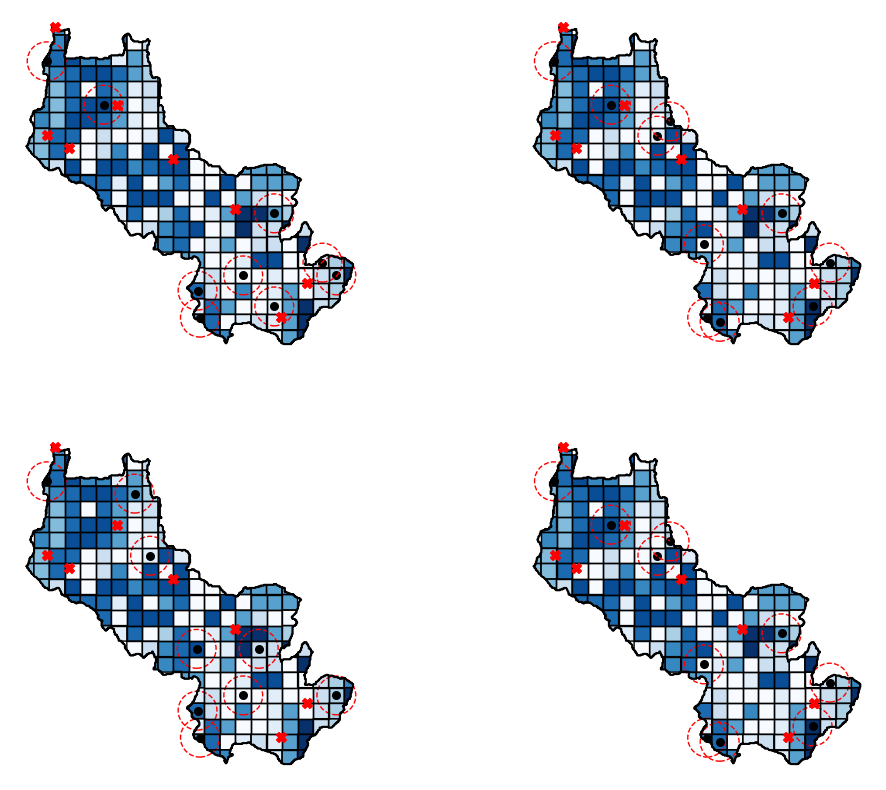

In [134]:
fig,axs=plt.subplots(ncols=2, nrows = 2, figsize=(12,10))
axs=axs.flatten()
greedy_cells = list(greedy_solution.values())
plot_selected_cells(axs[0], greedy_cells, min_dist)
axs[0].axis('off')

shuffle_cells = list(shuffle_solution.values())
plot_selected_cells(axs[1], shuffle_cells, min_dist)
axs[1].axis('off');

sim_anneal_cells = list(sim_anneal_solution.values())
plot_selected_cells(axs[2], sim_anneal_cells, min_dist)
axs[2].axis('off');

plot_selected_cells(axs[3], ilp_cells, min_dist)
axs[3].axis('off');

In [114]:
import time
import random
import numpy as np
from scipy.spatial.distance import cdist

# ── Shared scoring function ──────────────────────────────────────────────────
def evaluate_solution(selected_cells, cluster_candidates, cell_centroids, 
                      existing_coords, min_dist):
    """
    Returns a dict of diagnostics for a given solution.
    """
    results = {}
    
    # 1. Coverage: how many clusters got a gauge
    results["n_covered"] = len(selected_cells)
    results["n_clusters"] = len(cluster_candidates)
    results["coverage_pct"] = 100 * len(selected_cells) / len(cluster_candidates)
    
    # 2. Candidate quality: average rank of chosen candidates
    #    (0 = top candidate chosen, higher = had to fall back)
    ranks = []
    for c, sel in zip(cluster_candidates.keys(), selected_cells):
        candidates = list(cluster_candidates[c])
        if sel in candidates:
            ranks.append(candidates.index(sel))
        else:
            ranks.append(np.nan)
    results["mean_candidate_rank"] = np.nanmean(ranks)
    results["max_candidate_rank"]  = np.nanmax(ranks)
    results["rank_details"] = dict(zip(cluster_candidates.keys(), ranks))
    
    # 3. Spacing: min distance between any two selected gauges
    if len(selected_cells) > 1:
        coords = np.array([
            (cell_centroids.iloc[i].x, cell_centroids.iloc[i].y)
            for i in selected_cells
        ])
        dm = cdist(coords, coords)
        np.fill_diagonal(dm, np.inf)
        results["min_spacing_selected"] = dm.min()
        results["any_spacing_violation"] = bool((dm < min_dist).any())
    else:
        results["min_spacing_selected"] = np.nan
        results["any_spacing_violation"] = False
    
    # 4. Spacing vs existing gauges
    violations = []
    for i, idx in enumerate(selected_cells):
        pt = cell_centroids.iloc[idx]
        for ex in existing_coords:
            dist = np.linalg.norm(np.array([pt.x, pt.y]) - ex)
            if dist < min_dist:
                violations.append((i, dist))
    results["existing_gauge_violations"] = violations
    results["any_existing_violation"] = len(violations) > 0
    
    return results


def print_evaluation(label, results, runtime):
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(f"  Coverage:          {results['n_covered']}/{results['n_clusters']} "
          f"({results['coverage_pct']:.1f}%)")
    print(f"  Mean rank chosen:  {results['mean_candidate_rank']:.2f}  "
          f"(0 = always top candidate)")
    print(f"  Max rank chosen:   {results['max_candidate_rank']:.0f}")
    print(f"  Min gauge spacing: {results['min_spacing_selected']:.0f} m  "
          f"(threshold: {min_dist} m)")
    print(f"  Spacing violation: {results['any_spacing_violation']}")
    print(f"  Existing violation:{results['any_existing_violation']}")
    print(f"  Runtime:           {runtime:.2f}s")
    if results['any_spacing_violation'] or results['any_existing_violation']:
        print("  ⚠️  INVALID SOLUTION — constraint violated")
    else:
        print("  ✅ Valid solution")
    # Show which clusters had to fall back from top candidate
    fallbacks = {c: r for c, r in results['rank_details'].items() if r > 0}
    if fallbacks:
        print(f"  Clusters using fallback candidates: {fallbacks}")


# ── Option 0: your original greedy (baseline) ────────────────────────────────
t0 = time.time()
# ... your original code here, store result in original_cells ...
original_cells = greedy_cells  # replace with your actual result
t_original = time.time() - t0
res_original = evaluate_solution(original_cells, cluster_candidates, cell_centroids, existing_coords, min_dist)
print_evaluation("Option 0: Original greedy (fixed order)", res_original, t_original)


# ── Option 1: shuffle + repeat ───────────────────────────────────────────────
t0 = time.time()
# ... run Option 1, store best result in shuffle_cells ...
shuffle_cells = shuffle_cells  # replace with your actual result
t_shuffle = time.time() - t0
res_shuffle = evaluate_solution(shuffle_cells, cluster_candidates, cell_centroids, existing_coords, min_dist)
print_evaluation("Option 1: Shuffle + repeat (500 iter)", res_shuffle, t_shuffle)


# ── Option 3: ILP ────────────────────────────────────────────────────────────
t0 = time.time()
# ... run Option 3, store result in ilp_cells (or None if infeasible) ...
ilp_cells = ilp_cells       # replace with your actual result
t_ilp = time.time() - t0
if ilp_cells is not None:
    res_ilp = evaluate_solution(
        ilp_cells, cluster_candidates, cell_centroids, existing_coords, min_dist)
    print_evaluation("Option 3: ILP", res_ilp, t_ilp)
else:
    print("\nOption 3: ILP — INFEASIBLE")
    
# ── Option 3: ILP ────────────────────────────────────────────────────────────
t0 = time.time()
# ... run Option 3, store result in ilp_cells (or None if infeasible) ...
sim_anneal_cells = sim_anneal_cells       # replace with your actual result
t_sim_anneal = time.time() - t0
if sim_anneal_cells is not None:
    res_sim_anneal = evaluate_solution(
        sim_anneal_cells, cluster_candidates, cell_centroids, existing_coords, min_dist)
    print_evaluation("Option 3: ILP", res_sim_anneal, t_sim_anneal)
else:
    print("\nOption 3: ILP — INFEASIBLE")    


# ── Summary table ────────────────────────────────────────────────────────────
import pandas as pd
summary = pd.DataFrame({
    "Original greedy": res_original,
    "Shuffle+repeat":  res_shuffle,
    "Simulated anneal":  res_sim_anneal,
     "ILP":  res_ilp}).T[["n_covered", "coverage_pct", "mean_candidate_rank", 
      "min_spacing_selected", "any_spacing_violation"]]
print("\n", summary.to_string())


  Option 0: Original greedy (fixed order)
  Coverage:          9/10 (90.0%)
  Mean rank chosen:  2.11  (0 = always top candidate)
  Max rank chosen:   6
  Min gauge spacing: 2500 m  (threshold: 2500 m)
  Spacing violation: False
  Existing violation:False
  Runtime:           0.00s
  ✅ Valid solution
  Clusters using fallback candidates: {1: 1, 2: 1, 3: 1, 4: 6, 5: 1, 7: 4, 8: 5}

  Option 1: Shuffle + repeat (500 iter)
  Coverage:          10/10 (100.0%)
  Mean rank chosen:  nan  (0 = always top candidate)
  Max rank chosen:   nan
  Min gauge spacing: 2897 m  (threshold: 2500 m)
  Spacing violation: False
  Existing violation:False
  Runtime:           0.00s
  ✅ Valid solution

  Option 3: ILP
  Coverage:          10/10 (100.0%)
  Mean rank chosen:  0.60  (0 = always top candidate)
  Max rank chosen:   2
  Min gauge spacing: 2897 m  (threshold: 2500 m)
  Spacing violation: False
  Existing violation:True
  Runtime:           0.00s
  ⚠️  INVALID SOLUTION — constraint violated
  Cluste

/tmp/ipykernel_3108416/4238305816.py:28: RuntimeWarning: Mean of empty slice
  results["mean_candidate_rank"] = np.nanmean(ranks)
/tmp/ipykernel_3108416/4238305816.py:29: RuntimeWarning: All-NaN axis encountered
  results["max_candidate_rank"]  = np.nanmax(ranks)


---

### Simulated annealing

---

In [75]:

ilp_cells = ilp(cluster_candidates, min_dist)           

Status: Optimal


In [ ]:
# import geopandas as gpd

# grid_1km["cell_area"] = grid_1km.geometry.area
# intersection = gpd.overlay(
#     grid_1km,
#     catchment_Dolwen[["geometry"]],
#     how="intersection"
# )

# intersection["intersect_area"] = intersection.geometry.area

# coverage = intersection.groupby(intersection.index)["intersect_area"].sum()
# grid_1km["intersect_area"] = coverage
# grid_1km["intersect_area"] = grid_1km["intersect_area"].fillna(0)

# grid_1km["coverage"] = grid_1km["intersect_area"] / grid_1km["cell_area"]
# grid_1km

In [ ]:
# coords = np.column_stack([centroids.x, centroids.y])  # shape (n_cells, 2)

# selected_cells = []

# clusters = np.unique(labels)

# # 1. Initialise with one cluster (e.g. first)
# c0 = clusters[0]
# cluster_idx = np.where(labels == c0)[0]
# selected_cells.append(cluster_idx[0])  # or best representative

# # 2. Iterate over remaining clusters
# for c in clusters[1:]:
#     cluster_idx = np.where(labels == c)[0]
    
#     best_idx = None
#     best_score = -np.inf
    
#     for idx in cluster_idx:
#         point = coords[idx]
        
#         # distance to closest selected point
#         dists = [
#             np.linalg.norm(point - coords[s])
#             for s in selected_cells
#         ]
        
#         score = min(dists)  # maximise minimum distance
        
#         if score > best_score:
#             best_score = score
#             best_idx = idx
    
#     selected_cells.append(best_idx)

# gauge_locations = grid_1km.iloc[selected_cells]


In [ ]:
# import seaborn as sns
# sns.pairplot(gauge_locations, vars=["mean_dem", "mean_slope", 'mean_aspect'], hue="cluster", palette = 'viridis')

In [ ]:
# import rasterstats as rs

# rain_stats = rs.zonal_stats(
#     grid_1km,
#     HAD_Dolwen_ppn.mean(dim="time").values,
#     affine=HAD_Dolwen_ppn.rio.transform(),
#     stats="mean",
#     nodata=np.nan
# )

# grid_1km["rain"] = [r["mean"] for r in rain_stats]

In [ ]:
# import numpy as np
# from scipy.spatial.distance import pdist

# # 1. Get centroids
# centroids = grid_1km.geometry.centroid
# coords = np.array([(pt.x, pt.y) for pt in centroids])

# # 2. Get rainfall values
# rain = HAD_Dolwen_ppn.mean(dim="time").values.flatten()
# rain = rain[~np.isnan(rain)]

# # 3. Mask NaNs (CRITICAL)
# mask = ~np.isnan(rain)

# coords = coords[mask]
# values = rain[mask]

# # 4. Now compute distances + differences
# dists = pdist(coords)
# diffs = pdist(values.reshape(-1, 1))

# gamma = 0.5 * (diffs ** 2)

In [ ]:
# bins = np.linspace(0, dists.max(), 20)
# bin_idx = np.digitize(dists, bins)
# # 
# variogram = [gamma[bin_idx == i].mean() for i in range(1, len(bins))]


In [ ]:
# import matplotlib.pyplot as plt

# plt.plot(bins[1:], variogram, 'o-')
# plt.xlabel("Distance (m)")
# plt.ylabel("Semivariance")
# plt.title("Empirical Variogram")
# plt.show()

In [ ]:
# grid_1km_sf["max_elev"]   = [z["max"]  for z in dem_stats]
# grid_1km_sf["min_elev"]   = [z["min"]  for z in dem_stats]
# grid_1km_sf["mean_elev"]  = [z["mean"] for z in dem_stats]
# grid_1km_sf["var_elev"]   = [z["std"]**2 if z["std"] is not None else np.nan for z in dem_stats]
# grid_1km_sf["range_elev"] = grid_1km_sf["max_elev"] - grid_1km_sf["min_elev"]

# grid_1km_sf["mean_slope"] = [z["mean"] for z in slope_stats]
# grid_1km_sf["var_slope"]  = [z["std"]**2 if z["std"] is not None else np.nan for z in slope_stats]

# grid_1km_sf["mean_aspect"]= [z["mean"] for z in aspect_stats]
# grid_1km_sf["var_aspect"] = [z["std"]**2 if z["std"] is not None else np.nan for z in aspect_stats]

# grid_1km_sf["mean_tri"]   = [z["mean"] for z in tri_stats]
# grid_1km_sf["var_tri"]    = [z["std"]**2 if z["std"] is not None else np.nan for z in tri_stats]

# grid_1km_sf["mean_PPN"]   = [z["mean"] for z in ppn_stats]

# # ==============================================================
# Point grid and rain gauge spatial joins
# ==============================================================

# Intersect grid polygons with centroid points → keep terrain attributes per point
# point_1km_sf = gpd.sjoin(grid_1km_sf, grid_1km_point, how="inner", predicate="contains")
# point_1km_sf["x"] = grid_1km_xy[:, 0]
# point_1km_sf["y"] = grid_1km_xy[:, 1]

# # Join rain gauge metadata with grid cell attributes
# rain_meta_sf2 = gpd.sjoin(rain_meta_sf, grid_1km_sf, how="left", predicate="within")
# rain_meta_sf2 = rain_meta_sf2.iloc[:, :12]  # keep first 12 columns (matching R)

# rain_xy = np.array([(g.x, g.y) for g in rain_meta_sf2.geometry])
# rain_meta_sf2["x"] = rain_xy[:, 0]
# rain_meta_sf2["y"] = rain_xy[:, 1]

In [ ]:
HAD_Dolwen_ppn_mean
values = HAD_Dolwen_ppn.mean(dim="time").values.flatten()
values.shape

In [ ]:
# ==============================================================
# Plot: rain gauges, river network, mean rainfall, grid
# ==============================================================

fig, ax = plt.subplots(figsize=(10, 10))

# Mean rainfall raster
HAD_Dolwen_ppn_mean.plot( ax=ax,cmap="magma", alpha=0.8,add_colorbar=True,robust=True)

# Grid outlines
grid_1km.boundary.plot(ax=ax, color="grey", linewidth=1)

# River network
# river_net_Dolwen.plot(ax=ax, color="steelblue", linewidth=0.8)

# Rain gauges
rain_meta_sf.plot(ax=ax, color="red", markersize=30, zorder=5)

plt.title("Mean Annual Rainfall with Rain Gauges and Grid")
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================
# Create 1km polygon grid and centroid points
# ==============================================================

# Build 1km grid polygons clipped to catchment
from shapely.geometry import box

# Get raster bounds and build grid
xmin, ymin, xmax, ymax = catchment_Dolwen.total_bounds
cell_size = 1000

cols = np.arange(xmin, xmax, cell_size)
rows = np.arange(ymin, ymax, cell_size)

grid_polys = [box(x, y, x + cell_size, y + cell_size)
    for x in cols for y in rows]

grid_1km = gpd.GeoDataFrame(geometry=grid_polys, crs=ukgrid)

# Clip grid to catchment boundary
grid_1km = gpd.overlay(grid_1km, catchment_Dolwen[["geometry"]], how="intersection")
grid_1km = grid_1km.reset_index(drop=True)

# Get centroids
grid_1km_point = grid_1km.copy()
grid_1km_point["geometry"] = grid_1km.centroid

# Extract XY coordinates
grid_1km_xy = np.array(
    [(geom.x, geom.y) for geom in grid_1km_point.geometry])

# Quick plot to check
plt.scatter(grid_1km_xy[:, 0], grid_1km_xy[:, 1], s=2)
plt.title("1km Grid Centroids")
plt.axis("equal")
plt.show()